In [5]:
!pip install -q transformers>=4.37.0 accelerate sentencepiece trl protobuf flash-attn llmlingua peft --no-build-isolation

In [6]:
import transformers
print(f"Transformers version: {transformers.__version__}")

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Transformers version: 5.2.0
PyTorch: 2.9.0+cu126
CUDA available: True
GPU: NVIDIA H100 80GB HBM3


In [7]:
import os, re, time, json
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments
import matplotlib.pyplot as plt
import seaborn as sns
import glob


from peft import LoraConfig, get_peft_model, PeftModel, TaskType
from trl import SFTTrainer, SFTConfig
import shutil

from datasets import Dataset
from llmlingua import PromptCompressor
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="peft")

# Config
MODEL_NAME       = "Qwen/Qwen2.5-7B-Instruct"
MAX_SAMPLES      = 500
MAX_NEW_TOKENS   = 1024
EVAL_BATCH_SIZE  = 64
DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")


Device: cuda


In [8]:

matches = glob.glob('/kaggle/input/**/math_500_test.csv', recursive=True)
DATA_PATH = matches[0] if matches else '/kaggle/input/math-500/math_500_test.csv'
print(f"Loading from: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)[['Question', 'Answer']].head(MAX_SAMPLES).reset_index(drop=True)
print(f"Loaded {len(df)} questions")

Loading from: /kaggle/input/datasets/vybhavchaturvedi/math-500/math_500_test.csv
Loaded 500 questions


In [9]:
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    padding_side='left',
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
    # attn_implementation="flash_attention_2",  # TODO: Flash Attention - Qwen
)
model.eval()
model = torch.compile(model, mode="reduce-overhead")  # TODO - Add a cache for time optimization
print(f"Model on: {next(model.parameters()).device}")

Loading tokenizer...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Model on: cuda:0


In [10]:
def extract_boxed(text):
    text = str(text)
    # Try \boxed{...} with nested brace matching
    idx = text.find('\\boxed{')
    if idx != -1:
        depth, start, end = 1, idx + 7, idx + 7
        while end < len(text) and depth > 0:
            if text[end] == '{': depth += 1
            elif text[end] == '}': depth -= 1
            end += 1
        if depth == 0:
            return text[start:end-1]
    match = re.search(r'final answer is[:\s]*([^\n.]+)', text, re.IGNORECASE)
    return match.group(1).strip() if match else text.strip()

def normalize(ans):
    ans = str(ans).strip()
    ans = re.sub(r'\\text\{([^}]*)\}', r'\1', ans)
    ans = re.sub(r'\\frac\{([^}]*)\}\{([^}]*)\}', r'(\1)/(\2)', ans)
    return re.sub(r'[^\w.+\-/]', '', ans.lower())

def is_correct(pred, gt):
    p, g = normalize(extract_boxed(pred)), normalize(extract_boxed(gt))
    if p == g: return True
    try:
        return abs(float(p.replace('^','**')) - float(g.replace('^','**'))) < 1e-6
    except:
        return False

In [11]:
PROMPTS = {
    'Original':   "Solve the following math problem step by step...\n\nProblem: {question}",
    'BeConcise':  "Be concise. Solve the following math problem step by step. Put your final answer within \\boxed{{}}.\n\nProblem: {question}",
    'OnlyNumbers':"Only use numbers or equations. Solve the following math problem step by step. Put your final answer within \\boxed{{}}.\n\nProblem: {question}",
    'AbbreWords': "Abbreviate words as much as possible. Solve the following math problem step by step. Put your final answer within \\boxed{{}}.\n\nProblem: {question}",
    'LoRA_Guided':"Solve the following math problem. Be concise and skip unnecessary steps. Put your final answer within \\boxed{{}}.\n\nProblem: {question}",
    'LoRA_Soft':  "Solve the following math problem step by step. Be reasonably concise — avoid repetition but keep key reasoning steps. Put your final answer within \\boxed{{}}.\n\nProblem: {question}",
}




def make_prompt(question, method):
    prompt = PROMPTS[method].format(question=question)
    messages = [{"role": "user", "content": prompt}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

In [12]:
def evaluate_batched(df, method="Original", max_new_tokens=MAX_NEW_TOKENS, original_avg_tokens=None):
    all_responses    = []
    all_token_counts = []
    start_time       = time.time()

    prompts_indexed = [(i, make_prompt(row['Question'], method)) for i, row in df.iterrows()]

    #VYBAHV - Anukul to sort by prompt length to reduce padding
    prompts_indexed.sort(key=lambda x: len(x[1]))
    sorted_indices = [i for i, _ in prompts_indexed]
    prompts        = [p for _, p in prompts_indexed]

    for batch_start in tqdm(range(0, len(prompts), EVAL_BATCH_SIZE),
                             desc=f"{method} (bs={EVAL_BATCH_SIZE})"):
        batch_prompts = prompts[batch_start:batch_start + EVAL_BATCH_SIZE]

        inputs = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=2048,
        ).to(DEVICE)

        input_len = inputs['input_ids'].shape[1]

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        generated    = outputs[:, input_len:]
        token_counts = (generated != tokenizer.pad_token_id).sum(dim=1).tolist()
        all_token_counts.extend(token_counts)

        responses = tokenizer.batch_decode(generated, skip_special_tokens=True)
        all_responses.extend(responses)

        del outputs, inputs, generated
        torch.cuda.empty_cache()

    # Restore original order
    reordered_responses    = [None] * len(df)
    reordered_token_counts = [None] * len(df)
    for sorted_pos, orig_idx in enumerate(sorted_indices):
        reordered_responses[orig_idx]    = all_responses[sorted_pos]
        reordered_token_counts[orig_idx] = all_token_counts[sorted_pos]

    elapsed    = time.time() - start_time
    correct    = sum(is_correct(r, g) for r, g in zip(reordered_responses, df['Answer']))
    avg_tokens = sum(reordered_token_counts) / len(df)

    return {
        'Method':     method,
        'Accuracy':   round(100 * correct / len(df), 2),
        'Avg Tokens': round(avg_tokens, 2),
        'Latency(s)': round(elapsed / len(df), 3),
        'Act Ratio':  round(avg_tokens / original_avg_tokens if original_avg_tokens else 1.0, 3),
        'Correct':    correct,
        'Total':      len(df),
    }, reordered_responses, reordered_token_counts


In [21]:
all_results          = []
all_responses_dict   = {}
all_token_counts_dict = {}
checkpoint_path      = "/kaggle/working/tokenskip_checkpoint.json"

if os.path.exists(checkpoint_path):
    with open(checkpoint_path) as f:
        checkpoint = json.load(f)
    all_results       = checkpoint.get('results', [])
    completed_methods = {r['Method'] for r in all_results}
    print(f"Resuming: {completed_methods} already done")
else:
    completed_methods = set()

eval_start = time.time()

for method in ["Original", "BeConcise", "OnlyNumbers", "AbbreWords"]:
    if method in completed_methods:
        print(f"Skipping {method} (already done)")
        continue

    print(f"\n{'='*60}\nEvaluating: {method}\n{'='*60}")
    orig_tokens = next((r['Avg Tokens'] for r in all_results if r['Method'] == 'Original'), None)

    result, responses, token_counts = evaluate_batched(df, method=method, original_avg_tokens=orig_tokens)
    all_results.append(result)
    all_responses_dict[method]    = responses
    all_token_counts_dict[method] = token_counts
    print(f"{method}: {result['Accuracy']:.1f}% acc | {result['Avg Tokens']:.1f} tokens | {result['Latency(s)']:.2f}s/sample")

    with open(checkpoint_path, 'w') as f:
        json.dump({'results': all_results}, f)

orig_tokens = next(r['Avg Tokens'] for r in all_results if r['Method'] == 'Original')

for ratio in [0.9, 0.8, 0.7, 0.6, 0.5]:
    method_key = f"Truncation_{ratio}"
    if method_key in completed_methods:
        print(f"Skipping {method_key} (already done)")
        continue

    print(f"\n{'='*60}\nEvaluating: Truncation ratio={ratio}\n{'='*60}")
    max_tok = int(MAX_NEW_TOKENS * ratio)

    result, responses, token_counts = evaluate_batched(df, method="Original", max_new_tokens=max_tok, original_avg_tokens=orig_tokens)
    result['Method'] = method_key
    result['Ratio']  = ratio
    all_results.append(result)
    all_responses_dict[method_key]    = responses
    all_token_counts_dict[method_key] = token_counts   # store counts
    print(f"Truncation {ratio}: {result['Accuracy']:.1f}% acc | {result['Avg Tokens']:.1f} tokens")

    with open(checkpoint_path, 'w') as f:
        json.dump({'results': all_results}, f)

total_time = time.time() - eval_start
print(f"\nAll evaluations complete in {total_time/3600:.2f} hours")


Resuming: {'Truncation_0.8', 'BeConcise', 'OnlyNumbers', 'Truncation_0.5', 'Truncation_0.9', 'Truncation_0.6', 'Truncation_0.7', 'AbbreWords', 'Original'} already done
Skipping Original (already done)
Skipping BeConcise (already done)
Skipping OnlyNumbers (already done)
Skipping AbbreWords (already done)
Skipping Truncation_0.9 (already done)
Skipping Truncation_0.8 (already done)
Skipping Truncation_0.7 (already done)
Skipping Truncation_0.6 (already done)
Skipping Truncation_0.5 (already done)

All evaluations complete in 0.00 hours


In [22]:
final_df = pd.DataFrame(all_results)

orig_tokens = final_df[final_df['Method'] == 'Original']['Avg Tokens'].values[0]
orig_acc    = final_df[final_df['Method'] == 'Original']['Accuracy'].values[0]

final_df['Token Savings (%)'] = ((1 - final_df['Avg Tokens'] / orig_tokens) * 100).round(2)
final_df['Accuracy Drop']     = (orig_acc - final_df['Accuracy']).round(2)
final_df['Efficiency Score']  = (final_df['Accuracy'] / final_df['Avg Tokens'] * 100).round(3)

final_df.to_csv("/kaggle/working/tokenskip_results.csv", index=False)

print("=" * 70)
print("TOKENSKIP FULL RESULTS — MATH-500 (500 samples)")
print("=" * 70)
print(final_df[['Method', 'Accuracy', 'Avg Tokens', 'Token Savings (%)',
                 'Accuracy Drop', 'Act Ratio', 'Latency(s)']].to_string(index=False))
print("=" * 70)

ranked = final_df[['Method', 'Accuracy', 'Avg Tokens', 'Token Savings (%)',
                    'Efficiency Score']].sort_values('Efficiency Score', ascending=False)
print("\nEFFICIENCY RANKING")
print(ranked.to_string(index=False))

best_eff     = final_df[final_df['Method'] != 'Original'].sort_values('Efficiency Score', ascending=False).iloc[0]
most_savings = final_df.sort_values('Token Savings (%)', ascending=False).iloc[0]
best_acc     = final_df.sort_values('Accuracy', ascending=False).iloc[0]

print("\nKEY FINDINGS")
print("=" * 70)
print(f"Best Efficiency Method : {best_eff['Method']} (score={best_eff['Efficiency Score']:.3f})")
print(f"Most Token Savings     : {most_savings['Method']} ({most_savings['Token Savings (%)']:.1f}% saved)")
print(f"Best Accuracy          : {best_acc['Method']} ({best_acc['Accuracy']:.1f}%)")
print(f"Baseline (Original)    : {orig_acc:.1f}% acc, {orig_tokens:.0f} avg tokens")


TOKENSKIP FULL RESULTS — MATH-500 (500 samples)
        Method  Accuracy  Avg Tokens  Token Savings (%)  Accuracy Drop  Act Ratio  Latency(s)
      Original      68.4      557.91               0.00            0.0      1.000       0.542
     BeConcise      69.0      457.87              17.93           -0.6      0.821       0.524
   OnlyNumbers      53.6      350.41              37.19           14.8      0.628       0.520
    AbbreWords      69.6      487.37              12.64           -1.2      0.874       0.523
Truncation_0.9      66.4      547.74               1.82            2.0      0.982       0.475
Truncation_0.8      62.6      531.58               4.72            5.8      0.953       0.417
Truncation_0.7      60.0      506.77               9.17            8.4      0.908       0.359
Truncation_0.6      55.2      475.64              14.75           13.2      0.853       0.319
Truncation_0.5      44.6      433.01              22.39           23.8      0.776       0.267

EFFICIENCY 

In [23]:
tradeoff = final_df[['Method', 'Accuracy', 'Token Savings (%)', 'Accuracy Drop']].copy()
tradeoff['Acc Drop per 10% Savings'] = (
    tradeoff['Accuracy Drop'] / (tradeoff['Token Savings (%)'] / 10)
).round(3)
tradeoff.loc[tradeoff['Token Savings (%)'] <= 0, 'Acc Drop per 10% Savings'] = 0.0

print("ACCURACY-EFFICIENCY TRADEOFF")
print("(How much accuracy is lost per 10% token savings)")
print("=" * 70)
print(tradeoff.to_string(index=False))

ACCURACY-EFFICIENCY TRADEOFF
(How much accuracy is lost per 10% token savings)
        Method  Accuracy  Token Savings (%)  Accuracy Drop  Acc Drop per 10% Savings
      Original      68.4               0.00            0.0                     0.000
     BeConcise      69.0              17.93           -0.6                    -0.335
   OnlyNumbers      53.6              37.19           14.8                     3.980
    AbbreWords      69.6              12.64           -1.2                    -0.949
Truncation_0.9      66.4               1.82            2.0                    10.989
Truncation_0.8      62.6               4.72            5.8                    12.288
Truncation_0.7      60.0               9.17            8.4                     9.160
Truncation_0.6      55.2              14.75           13.2                     8.949
Truncation_0.5      44.6              22.39           23.8                    10.630


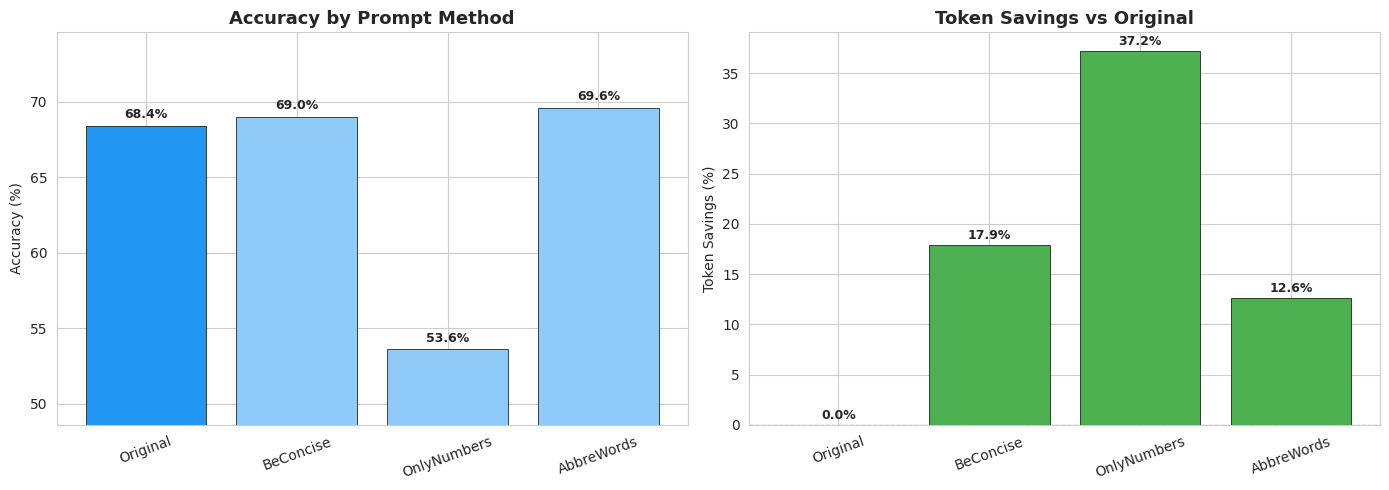

In [24]:
prompt_df = final_df[~final_df['Method'].str.contains("Truncation")].copy()

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3' if m == 'Original' else '#90CAF9' for m in prompt_df['Method']]
bars = axes[0].bar(prompt_df['Method'], prompt_df['Accuracy'],
                    color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title("Accuracy by Prompt Method", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(prompt_df['Accuracy'].min() - 5, prompt_df['Accuracy'].max() + 5)
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, prompt_df['Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

colors2 = ['#4CAF50' if s > 0 else '#F44336' for s in prompt_df['Token Savings (%)']]
bars2 = axes[1].bar(prompt_df['Method'], prompt_df['Token Savings (%)'],
                     color=colors2, edgecolor='black', linewidth=0.5)
axes[1].set_title("Token Savings vs Original", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Token Savings (%)")
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars2, prompt_df['Token Savings (%)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("/kaggle/working/prompt_methods.png", dpi=300, bbox_inches='tight')
plt.show()


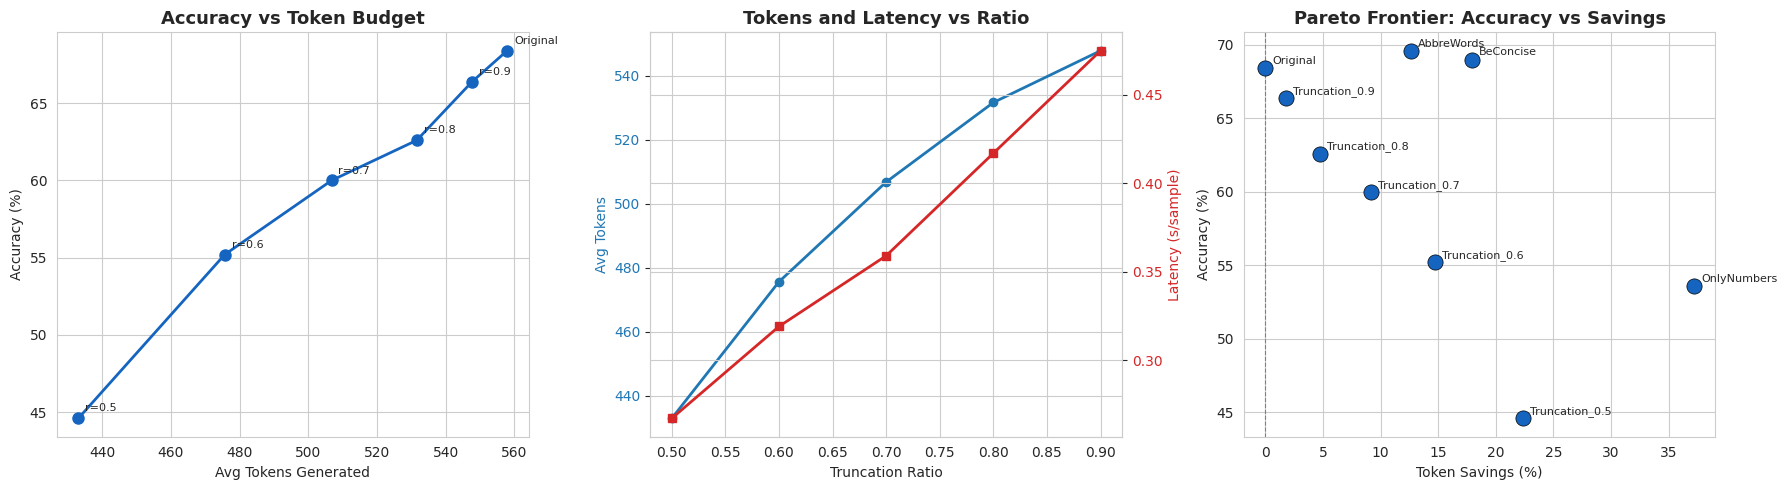

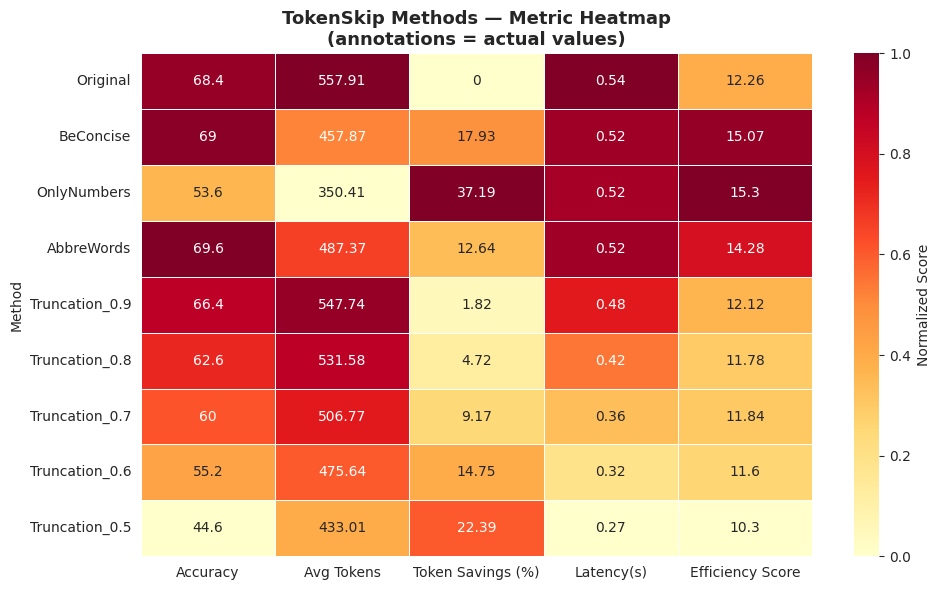

In [25]:
trunc_df = final_df[final_df['Method'].str.contains("Truncation")].copy().sort_values('Ratio')
trunc_with_orig = pd.concat([
    final_df[final_df['Method'] == 'Original'],
    trunc_df
]).sort_values('Avg Tokens')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(trunc_with_orig['Avg Tokens'], trunc_with_orig['Accuracy'],
             'o-', color='#1565C0', linewidth=2, markersize=8)
for _, row in trunc_with_orig.iterrows():
    label = f"r={row['Ratio']}" if pd.notna(row.get('Ratio')) else 'Original'
    axes[0].annotate(label, (row['Avg Tokens'], row['Accuracy']),
                     textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[0].set_xlabel("Avg Tokens Generated")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Accuracy vs Token Budget", fontsize=13, fontweight='bold')

ax1 = axes[1]
ax2 = ax1.twinx()
ax1.plot(trunc_df['Ratio'], trunc_df['Avg Tokens'], 'o-', color='tab:blue', linewidth=2)
ax2.plot(trunc_df['Ratio'], trunc_df['Latency(s)'], 's-', color='tab:red', linewidth=2)
ax1.set_xlabel("Truncation Ratio")
ax1.set_ylabel("Avg Tokens", color='tab:blue')
ax2.set_ylabel("Latency (s/sample)", color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
axes[1].set_title("Tokens and Latency vs Ratio", fontsize=13, fontweight='bold')

axes[2].scatter(final_df['Token Savings (%)'], final_df['Accuracy'],
                s=120, c='#1565C0', zorder=5, edgecolors='black', linewidth=0.5)
for _, row in final_df.iterrows():
    axes[2].annotate(row['Method'], (row['Token Savings (%)'], row['Accuracy']),
                     textcoords="offset points", xytext=(5, 3), fontsize=8)
axes[2].set_xlabel("Token Savings (%)")
axes[2].set_ylabel("Accuracy (%)")
axes[2].set_title("Pareto Frontier: Accuracy vs Savings", fontsize=13, fontweight='bold')
axes[2].axvline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig("/kaggle/working/truncation_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

# Heatmap
pivot = final_df[['Method', 'Accuracy', 'Avg Tokens', 'Token Savings (%)',
                   'Latency(s)', 'Efficiency Score']].set_index('Method')
pivot_norm = (pivot - pivot.min()) / (pivot.max() - pivot.min())

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_norm, annot=pivot.round(2), fmt='g', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalized Score'})
ax.set_title("TokenSkip Methods — Metric Heatmap\n(annotations = actual values)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/method_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


In [26]:
print(pd.read_csv(DATA_PATH).columns.tolist())

from datasets import load_dataset

ds     = load_dataset("HuggingFaceH4/MATH-500", split="test")
df_meta = ds.to_pandas()
df_meta = df_meta.rename(columns={'problem': 'Question'})[['Question', 'level', 'subject']]

df = df.drop(columns=[c for c in ['level', 'subject', 'Question_norm'] if c in df.columns])

df['Question_norm']      = df['Question'].str.strip().str.replace(r'\s+', ' ', regex=True)
df_meta['Question_norm'] = df_meta['Question'].str.strip().str.replace(r'\s+', ' ', regex=True)

df = df.merge(df_meta[['Question_norm', 'level', 'subject']],
              on='Question_norm', how='left')
df = df.drop(columns='Question_norm')

print(f"Matched: {df['level'].notna().sum()} / {len(df)}")
print(df[['Question', 'level', 'subject']].head(3))


['Question', 'Answer']


README.md:   0%|          | 0.00/412 [00:00<?, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

Matched: 500 / 500
                                            Question  level  \
0  Convert the point $(0,3)$ in rectangular coord...      2   
1  Define\n\[p = \sum_{k = 1}^\infty \frac{1}{k^2...      5   
2  If $f(x) = \frac{3x-2}{x-2}$, what is the valu...      3   

                subject  
0           Precalculus  
1  Intermediate Algebra  
2               Algebra  


In [27]:
LEVEL_COL   = 'level'
SUBJECT_COL = 'subject'

original_responses = all_responses_dict.get('Original', [])
df['Predicted']    = original_responses
df['Correct']      = [is_correct(p, g) for p, g in zip(original_responses, df['Answer'])]

level_acc = df.groupby(LEVEL_COL)['Correct'].agg(['sum', 'count'])
level_acc['Accuracy'] = (100 * level_acc['sum'] / level_acc['count']).round(2)
print("\nACCURACY BY DIFFICULTY LEVEL")
print(level_acc[['sum', 'count', 'Accuracy']].rename(
    columns={'sum': 'Correct', 'count': 'Total'}).to_string())

type_acc = df.groupby(SUBJECT_COL)['Correct'].agg(['sum', 'count'])
type_acc['Accuracy'] = (100 * type_acc['sum'] / type_acc['count']).round(2)
print("\nACCURACY BY SUBJECT TYPE")
print(type_acc[['sum', 'count', 'Accuracy']].rename(
    columns={'sum': 'Correct', 'count': 'Total'}).to_string())


ValueError: Length of values (0) does not match length of index (500)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

level_acc_sorted = level_acc.sort_index()
axes[0].bar(level_acc_sorted.index.astype(str), level_acc_sorted['Accuracy'],
            color='#1565C0', edgecolor='black', linewidth=0.5)
axes[0].set_title("Accuracy by Difficulty Level", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Level")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 100)
for i, (idx, row) in enumerate(level_acc_sorted.iterrows()):
    axes[0].text(i, row['Accuracy'] + 1, f"{row['Accuracy']:.1f}%",
                 ha='center', fontsize=9, fontweight='bold')

type_acc_sorted = type_acc.sort_values('Accuracy', ascending=True)
axes[1].barh(type_acc_sorted.index, type_acc_sorted['Accuracy'],
             color='#42A5F5', edgecolor='black', linewidth=0.5)
axes[1].set_title("Accuracy by Subject Type", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Accuracy (%)")
axes[1].set_xlim(0, 100)
for i, (idx, row) in enumerate(type_acc_sorted.iterrows()):
    axes[1].text(row['Accuracy'] + 0.5, i, f"{row['Accuracy']:.1f}%",
                 va='center', fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/category_breakdown.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
tradeoff = final_df[['Method', 'Accuracy', 'Token Savings (%)', 'Accuracy Drop']].copy()
tradeoff['Acc Drop per 10% Savings'] = (
    tradeoff['Accuracy Drop'] / (tradeoff['Token Savings (%)'] / 10)
).round(3)
tradeoff.loc[tradeoff['Token Savings (%)'] <= 0, 'Acc Drop per 10% Savings'] = 0.0

print("ACCURACY-EFFICIENCY TRADEOFF")
print("(How much accuracy is lost per 10% token savings)")
print("=" * 70)
print(tradeoff.to_string(index=False))


In [ ]:
token_dist_data = []
for method, counts in all_token_counts_dict.items():
    for count in counts:
        token_dist_data.append({'Method': method, 'Tokens': count})

token_dist_df = pd.DataFrame(token_dist_data)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=token_dist_df, x='Method', y='Tokens', palette='Blues', ax=ax)
ax.set_title("Token Length Distribution per Method", fontsize=13, fontweight='bold')
ax.set_xlabel("")
ax.set_ylabel("Generated Tokens")
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig("/kaggle/working/token_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

## LLMLingua compression

In [ ]:

!wget -q https://raw.githubusercontent.com/vybhav72954/tokenship/master/Outputs/qwen2.5/math500/tokenskip_checkpoint.json \
     -O /kaggle/working/tokenskip_checkpoint.json

with open('/kaggle/working/tokenskip_checkpoint.json') as f:
    checkpoint = json.load(f)
all_results = checkpoint.get('results', [])
print(f"Loaded {len(all_results)} results from checkpoint")


In [ ]:
# Re-run Original to capture raw CoT text (not in checkpoint)
print("Re-running Original to capture raw CoT...")
result, responses, token_counts = evaluate_batched(df, method='Original')

records = [
    {
        "id": i,
        "problem": df.iloc[i]['Question'],
        "answer": df.iloc[i]['Answer'],
        "full_cot": r,
        "token_count": t
    }
    for i, (r, t) in enumerate(zip(responses, token_counts))
]

with open('/kaggle/working/math500_original_cot.jsonl', 'w') as f:
    for rec in records:
        f.write(json.dumps(rec) + '\n')

print(f"Saved {len(records)} CoT traces to math500_original_cot.jsonl")


In [ ]:
compressor = PromptCompressor(
    model_name="microsoft/llmlingua-2-xlm-roberta-large-meetingbank",
    use_llmlingua2=True,
    device_map="cuda"
)

with open('/kaggle/working/math500_original_cot.jsonl') as f:
    cot_records = [json.loads(l) for l in f]

for ratio in [0.5, 0.6, 0.7]:
    compressed = []
    for rec in tqdm(cot_records, desc=f"Compressing ratio={ratio}"):
        result = compressor.compress_prompt(
            rec['full_cot'],
            rate=ratio,
            force_tokens=['\n', '?', '=']
        )
        compressed.append({
            "id": rec['id'],
            "problem": rec['problem'],
            "answer": rec['answer'],
            "full_cot": rec['full_cot'],
            "compressed_cot": result['compressed_prompt'],
            "original_tokens": rec['token_count'],
            "compressed_ratio": ratio
        })

    out = f'/kaggle/working/math500_compressed_ratio{ratio}.jsonl'
    with open(out, 'w') as f:
        for r in compressed:
            f.write(json.dumps(r) + '\n')
    print(f"ratio={ratio}: saved {len(compressed)} records → {out}")


In [ ]:
def evaluate_llmlingua(compressed_path, ratio_label, original_avg_tokens):
    with open(compressed_path) as f:
        records = [json.loads(l) for l in f]

    all_responses = []
    all_token_counts = []
    start_time = time.time()

    # Build prompts using compressed CoT as the problem context
    prompts_indexed = []
    for i, rec in enumerate(records):
        messages = [{"role": "user", "content": rec['compressed_cot']}]
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        prompts_indexed.append((i, prompt))

    prompts_indexed.sort(key=lambda x: len(x[1]))
    sorted_indices = [i for i, _ in prompts_indexed]
    prompts = [p for _, p in prompts_indexed]

    for batch_start in tqdm(range(0, len(prompts), EVAL_BATCH_SIZE), desc=f"LLMLingua_{ratio_label}"):
        batch_prompts = prompts[batch_start:batch_start + EVAL_BATCH_SIZE]
        inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True,
                           truncation=True, max_length=2048).to(DEVICE)
        input_len = inputs['input_ids'].shape[1]
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS,
                                     do_sample=False, pad_token_id=tokenizer.pad_token_id,
                                     eos_token_id=tokenizer.eos_token_id)
        generated = outputs[:, input_len:]
        token_counts = (generated != tokenizer.pad_token_id).sum(dim=1).tolist()
        responses = tokenizer.batch_decode(generated, skip_special_tokens=True)
        all_responses.extend(responses)
        all_token_counts.extend(token_counts)
        del outputs, inputs, generated
        torch.cuda.empty_cache()

    # Restore original order
    reordered_responses = [None] * len(records)
    reordered_token_counts = [None] * len(records)
    for sorted_pos, orig_idx in enumerate(sorted_indices):
        reordered_responses[orig_idx] = all_responses[sorted_pos]
        reordered_token_counts[orig_idx] = all_token_counts[sorted_pos]

    elapsed = time.time() - start_time
    correct = sum(is_correct(r, rec['answer']) for r, rec in zip(reordered_responses, records))
    avg_tokens = sum(reordered_token_counts) / len(records)

    return {
        'Method': f'LLMLingua_{ratio_label}',
        'Accuracy': round(100 * correct / len(records), 2),
        'Avg Tokens': round(avg_tokens, 2),
        'Latency(s)': round(elapsed / len(records), 3),
        'Act Ratio': round(avg_tokens / original_avg_tokens, 3),
        'Correct': correct,
        'Total': len(records),
        'Ratio': ratio_label
    }

In [ ]:
orig_tokens = 557.91  # from your baseline
lingua_results = []

for ratio in [0.5, 0.6, 0.7]:
    path = f'/kaggle/working/math500_compressed_ratio{ratio}.jsonl'
    result = evaluate_llmlingua(path, ratio, orig_tokens)
    lingua_results.append(result)
    print(f"LLMLingua_{ratio}: {result['Accuracy']:.1f}% acc | {result['Avg Tokens']:.1f} tokens | "
          f"{result['Act Ratio']:.3f} ratio")

In [ ]:
!wget -q https://raw.githubusercontent.com/vybhav72954/tokenship/master/Outputs/qwen2.5/math500/tokenskip_results.csv \
     -O /kaggle/working/tokenskip_results.csv

existing_df = pd.read_csv('/kaggle/working/tokenskip_results.csv')
lingua_df = pd.DataFrame(lingua_results)
lingua_df['Token Savings (%)'] = ((1 - lingua_df['Avg Tokens'] / orig_tokens) * 100).round(2)
lingua_df['Accuracy Drop'] = (68.4 - lingua_df['Accuracy']).round(2)
lingua_df['Efficiency Score'] = (lingua_df['Accuracy'] / lingua_df['Avg Tokens'] * 100).round(3)

full_df = pd.concat([existing_df, lingua_df], ignore_index=True)
full_df.to_csv('/kaggle/working/tokenskip_full_results.csv', index=False)
print(full_df[['Method', 'Accuracy', 'Avg Tokens', 'Token Savings (%)', 'Accuracy Drop']].to_string(index=False))


## LoRA Training

In [ ]:
# Install LoRA deps
!pip install peft trl -q


In [ ]:


# Load compressed CoT data
with open('/kaggle/working/math500_compressed_ratio0.7.jsonl') as f:
    records = [json.loads(l) for l in f]

# Format as instruction-following pairs
def format_record(rec):
    return {
        "text": tokenizer.apply_chat_template([
            {"role": "user",    "content": PROMPTS["Original"].format(question=rec["problem"])},
            {"role": "assistant","content": rec["compressed_cot"]}
        ], tokenize=False)
    }

train_dataset = Dataset.from_list([format_record(r) for r in records])
print(f"Training samples: {len(train_dataset)}")

In [ ]:
model = model._orig_mod  # ← unwrap compiled model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

peft_model = get_peft_model(model, lora_config)
peft_model.print_trainable_parameters()

In [ ]:
training_args = SFTConfig(
    output_dir="/kaggle/working/qwen_lora_compressed",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    bf16=True,
    logging_steps=10,
    save_strategy="epoch",
    warmup_steps=50,            #VYBHAV - Read replaced warmup_ratio doc
    lr_scheduler_type="cosine",
    max_length=2048,
    dataset_text_field="text",
    report_to="none"
)

trainer = SFTTrainer(
    model=peft_model,
    train_dataset=train_dataset,
    args=training_args,
)

trainer.train()
peft_model.save_pretrained("/kaggle/working/qwen_lora_compressed")
print("LoRA adapters saved!")

In [ ]:
# Zip the entire LoRA output folder
shutil.make_archive(
    '/kaggle/working/qwen_lora_compressed',  # output zip name
    'zip',
    '/kaggle/working/qwen_lora_compressed'   # folder to zip
)

print("Done! Download: /kaggle/working/qwen_lora_compressed.zip")

In [ ]:
# Load LoRA model for inference
lora_model = PeftModel.from_pretrained(
    model,
    "/kaggle/working/qwen_lora_compressed"
)
lora_model.eval()

# Evaluate on MATH-500 (same 500 problems)
result, responses, token_counts = evaluate_batched(
    df,
    method='Original',          # same prompt, model does compression natively
    original_avg_tokens=557.91
)
result['Method'] = 'LoRA_LLMLingua_0.7'

print(f"\n{'='*60}")
print(f"LoRA Result: {result['Accuracy']:.1f}% acc | {result['Avg Tokens']:.1f} tokens")
print(f"Token Savings: {result['Token Savings (%)'] if 'Token Savings (%)' in result else ((1 - result['Avg Tokens']/557.91)*100):.1f}%")
print(f"vs Original:  68.4% acc | 557.9 tokens")
print(f"vs Truncation_0.7: 60.0% acc | 506.8 tokens")
print(f"{'='*60}")


## LoRA Evalutaion

Adapters trained in `tokenship-lora-training.ipynb`. Evaluated here on MATH-500 test set.
Input dataset required: `tokenskip-lora-adapters` (3 ZIPs, one per compression ratio).

In [13]:
BASE = "https://raw.githubusercontent.com/vybhav72954/tokenship/master/Outputs/qwen2.5/math500"
!wget -q {BASE}/tokenskip_checkpoint.json -O /kaggle/working/tokenskip_checkpoint.json
!wget -q {BASE}/tokenskip_results.csv     -O /kaggle/working/tokenskip_results.csv

In [14]:
ORIG_AVG_TOKENS = 557.91
ADAPTER_INPUT   = "/kaggle/input/datasets/vybhavchaturvedi/tokenskip-lora-adapters-qwen2-5"
EVAL_BATCH_SIZE = 64  # resolves the EVAL_BATCH_SIZE NameError

for ratio in [0.5, 0.6, 0.7]:
    path = f"{ADAPTER_INPUT}/qwen_lora_ratio_{ratio:.1f}"
    exists = os.path.exists(path)
    print(f"ratio={ratio}  →  {path}  {'mil gya' if exists else 'nhi mila'}")

ratio=0.5  →  /kaggle/input/datasets/vybhavchaturvedi/tokenskip-lora-adapters-qwen2-5/qwen_lora_ratio_0.5  mil gya
ratio=0.6  →  /kaggle/input/datasets/vybhavchaturvedi/tokenskip-lora-adapters-qwen2-5/qwen_lora_ratio_0.6  mil gya
ratio=0.7  →  /kaggle/input/datasets/vybhavchaturvedi/tokenskip-lora-adapters-qwen2-5/qwen_lora_ratio_0.7  mil gya


In [15]:
lora_results = []
for ratio in [0.5, 0.6, 0.7]:
    adapter_path = f"{ADAPTER_INPUT}/qwen_lora_ratio_{ratio:.1f}"
    print(f"\n{'='*60}\nEvaluating LoRA Original | ratio={ratio}\n{'='*60}")
    lora_model = PeftModel.from_pretrained(model, adapter_path)
    lora_model.eval()
    original_model = model
    globals()['model'] = lora_model
    result, _, _ = evaluate_batched(df, method='Original', original_avg_tokens=ORIG_AVG_TOKENS)
    result['Method'] = f'LoRA_{ratio}'
    result['Token Savings (%)'] = round((1 - result['Avg Tokens'] / ORIG_AVG_TOKENS) * 100, 2)
    result['Accuracy Drop']     = round(68.4 - result['Accuracy'], 2)
    lora_results.append(result)
    print(f"  Accuracy: {result['Accuracy']:.1f}% | Tokens: {result['Avg Tokens']:.1f} | Savings: {result['Token Savings (%)']:.1f}%")
    globals()['model'] = original_model
    del lora_model; torch.cuda.empty_cache()


Evaluating LoRA Original | ratio=0.5


Original (bs=64):   0%|          | 0/8 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Accuracy: 62.6% | Tokens: 598.8 | Savings: -7.3%

Evaluating LoRA Original | ratio=0.6


Original (bs=64):   0%|          | 0/8 [00:00<?, ?it/s]

  Accuracy: 61.6% | Tokens: 603.4 | Savings: -8.2%

Evaluating LoRA Original | ratio=0.7


Original (bs=64):   0%|          | 0/8 [00:00<?, ?it/s]

  Accuracy: 62.2% | Tokens: 597.0 | Savings: -7.0%


In [16]:
lora_results_guided = []  # ← its own list
for ratio in [0.5, 0.6, 0.7]:
    adapter_path = f"{ADAPTER_INPUT}/qwen_lora_ratio_{ratio:.1f}"
    print(f"\n{'='*60}\nEvaluating LoRA Guided | ratio={ratio}\n{'='*60}")
    lora_model = PeftModel.from_pretrained(model, adapter_path)
    lora_model.eval()
    original_model = model
    globals()['model'] = lora_model
    result, _, _ = evaluate_batched(df, method='LoRA_Guided', original_avg_tokens=ORIG_AVG_TOKENS)
    result['Method'] = f'LoRA_Guided_{ratio}'
    result['Token Savings (%)'] = round((1 - result['Avg Tokens'] / ORIG_AVG_TOKENS) * 100, 2)
    result['Accuracy Drop']     = round(68.4 - result['Accuracy'], 2)
    lora_results_guided.append(result)
    print(f"  Accuracy: {result['Accuracy']:.1f}% | Tokens: {result['Avg Tokens']:.1f} | Savings: {result['Token Savings (%)']:.1f}%")
    globals()['model'] = original_model
    del lora_model; torch.cuda.empty_cache()



Evaluating LoRA Guided | ratio=0.5


LoRA_Guided (bs=64):   0%|          | 0/8 [00:00<?, ?it/s]

  Accuracy: 50.0% | Tokens: 299.9 | Savings: 46.2%

Evaluating LoRA Guided | ratio=0.6


LoRA_Guided (bs=64):   0%|          | 0/8 [00:00<?, ?it/s]

  Accuracy: 49.6% | Tokens: 302.0 | Savings: 45.9%

Evaluating LoRA Guided | ratio=0.7


LoRA_Guided (bs=64):   0%|          | 0/8 [00:00<?, ?it/s]

  Accuracy: 49.0% | Tokens: 302.9 | Savings: 45.7%


In [17]:
lora_soft_results = []  # ← its OWN separate list, NOT lora_results_guided
for ratio in [0.5, 0.6, 0.7]:
    adapter_path = f"{ADAPTER_INPUT}/qwen_lora_ratio_{ratio:.1f}"
    print(f"\n{'='*60}\nEvaluating LoRA Soft | ratio={ratio}\n{'='*60}")
    lora_model = PeftModel.from_pretrained(model, adapter_path)
    lora_model.eval()
    original_model = model
    globals()['model'] = lora_model
    result, _, _ = evaluate_batched(df, method='LoRA_Soft', original_avg_tokens=ORIG_AVG_TOKENS)
    result['Method'] = f'LoRA_Soft_{ratio}'
    result['Token Savings (%)'] = round((1 - result['Avg Tokens'] / ORIG_AVG_TOKENS) * 100, 2)
    result['Accuracy Drop']     = round(68.4 - result['Accuracy'], 2)
    lora_soft_results.append(result)  # ← appends to correct list
    print(f"  Accuracy: {result['Accuracy']:.1f}% | Tokens: {result['Avg Tokens']:.1f} | Savings: {result['Token Savings (%)']:.1f}%")
    globals()['model'] = original_model
    del lora_model; torch.cuda.empty_cache()


Evaluating LoRA Soft | ratio=0.5


LoRA_Soft (bs=64):   0%|          | 0/8 [00:00<?, ?it/s]

  Accuracy: 67.4% | Tokens: 503.7 | Savings: 9.7%

Evaluating LoRA Soft | ratio=0.6


LoRA_Soft (bs=64):   0%|          | 0/8 [00:00<?, ?it/s]

  Accuracy: 69.0% | Tokens: 503.6 | Savings: 9.7%

Evaluating LoRA Soft | ratio=0.7


LoRA_Soft (bs=64):   0%|          | 0/8 [00:00<?, ?it/s]

  Accuracy: 67.2% | Tokens: 501.6 | Savings: 10.1%


In [18]:
existing_df   = pd.read_csv('/kaggle/working/tokenskip_results.csv')
lora_df       = pd.DataFrame(lora_results)
lora_guide_df = pd.DataFrame(lora_results_guided)
lora_soft_df  = pd.DataFrame(lora_soft_results)

# Ensure Token Savings and Accuracy Drop columns exist on all frames
ORIG_TOKENS = 557.91
ORIG_ACC    = 68.4

for df_ in [lora_df, lora_guide_df, lora_soft_df]:
    if 'Token Savings (%)' not in df_.columns:
        df_['Token Savings (%)'] = ((1 - df_['Avg Tokens'] / ORIG_TOKENS) * 100).round(2)
    if 'Accuracy Drop' not in df_.columns:
        df_['Accuracy Drop'] = (ORIG_ACC - df_['Accuracy']).round(2)

final_df = pd.concat([existing_df, lora_df, lora_guide_df, lora_soft_df], ignore_index=True)
final_df.to_csv('/kaggle/working/tokenskip_results_final.csv', index=False)

print("=" * 68)
print("FINAL RESULTS — All Methods")
print("=" * 68)
print(final_df[['Method', 'Accuracy', 'Avg Tokens', 'Token Savings (%)', 'Accuracy Drop']].to_string(index=False))

FINAL RESULTS — All Methods
         Method  Accuracy  Avg Tokens  Token Savings (%)  Accuracy Drop
       Original      68.4      557.91               0.00            0.0
      BeConcise      69.0      457.87              17.93           -0.6
    OnlyNumbers      53.6      350.41              37.19           14.8
     AbbreWords      69.6      487.37              12.64           -1.2
 Truncation_0.9      66.4      547.74               1.82            2.0
 Truncation_0.8      62.6      531.58               4.72            5.8
 Truncation_0.7      60.0      506.77               9.17            8.4
 Truncation_0.6      55.2      475.64              14.75           13.2
 Truncation_0.5      44.6      433.01              22.39           23.8
       LoRA_0.5      62.6      598.82              -7.33            5.8
       LoRA_0.6      61.6      603.41              -8.16            6.8
       LoRA_0.7      62.2      596.95              -7.00            6.2
LoRA_Guided_0.5      50.0      299.9

In [19]:
trunc       = final_df[final_df['Method'].str.startswith('Truncation')].sort_values('Token Savings (%)')
lora_orig   = final_df[final_df['Method'].str.match(r'^LoRA_[0-9]')].sort_values('Token Savings (%)')
lora_guided = final_df[final_df['Method'].str.startswith('LoRA_Guided')].sort_values('Token Savings (%)')
lora_soft   = final_df[final_df['Method'].str.startswith('LoRA_Soft')].sort_values('Token Savings (%)')

COLORS = {
    'trunc':   'tomato',
    'orig':    '#90CAF9',
    'guided':  'darkorange',
    'soft':    'steelblue',
    'prompt':  'mediumpurple',
    'origin':  '#555555',
}

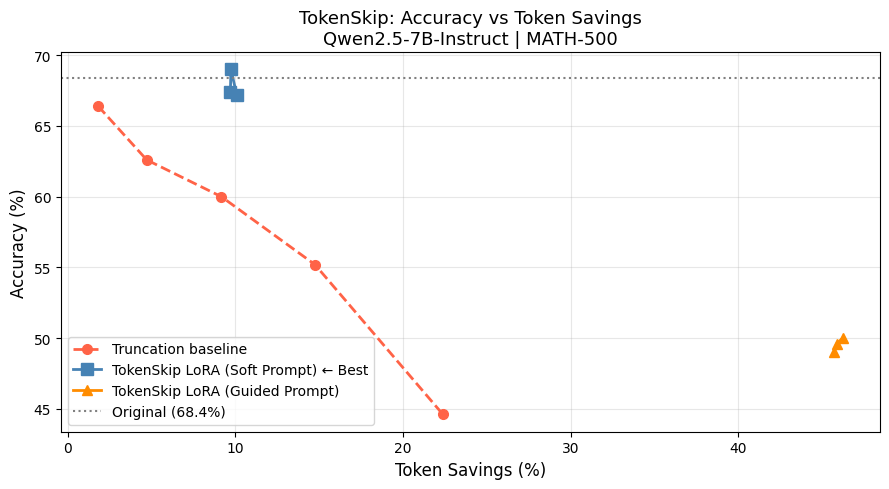

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(trunc['Token Savings (%)'],       trunc['Accuracy'],       'o--', color=COLORS['trunc'],  lw=2, ms=7, label='Truncation baseline')
ax.plot(lora_soft['Token Savings (%)'],   lora_soft['Accuracy'],   's-',  color=COLORS['soft'],   lw=2, ms=8, label='TokenSkip LoRA (Soft Prompt) ← Best')
ax.plot(lora_guided['Token Savings (%)'], lora_guided['Accuracy'], '^-',  color=COLORS['guided'], lw=2, ms=7, label='TokenSkip LoRA (Guided Prompt)')
ax.axhline(ORIG_ACC, linestyle=':', color='gray', lw=1.5, label=f'Original ({ORIG_ACC}%)')
ax.set_xlabel('Token Savings (%)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('TokenSkip: Accuracy vs Token Savings\nQwen2.5-7B-Instruct | MATH-500', fontsize=13)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/fig1_main_accuracy_vs_savings.png', dpi=300, bbox_inches='tight')
plt.show()

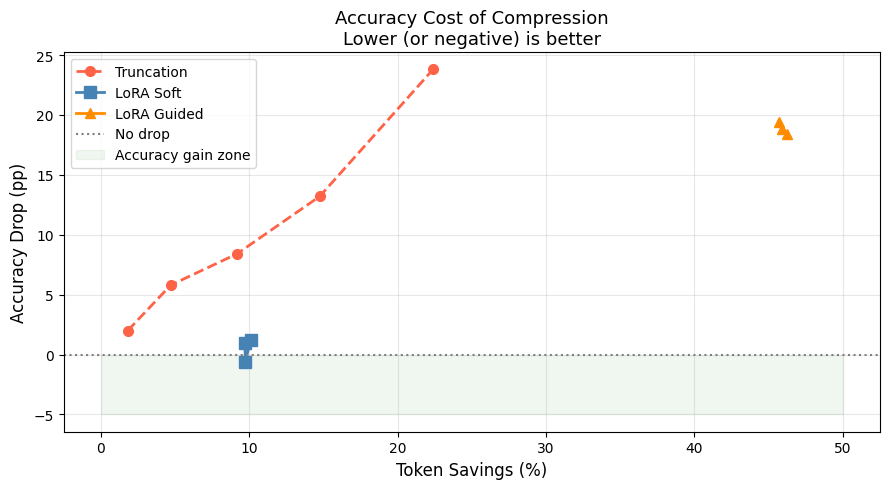

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(trunc['Token Savings (%)'],       trunc['Accuracy Drop'],       'o--', color=COLORS['trunc'],  lw=2, ms=7, label='Truncation')
ax.plot(lora_soft['Token Savings (%)'],   lora_soft['Accuracy Drop'],   's-',  color=COLORS['soft'],   lw=2, ms=8, label='LoRA Soft')
ax.plot(lora_guided['Token Savings (%)'], lora_guided['Accuracy Drop'], '^-',  color=COLORS['guided'], lw=2, ms=7, label='LoRA Guided')
ax.axhline(0, linestyle=':', color='gray', lw=1.5, label='No drop')
ax.fill_between([0, 50], 0, -5, alpha=0.06, color='green', label='Accuracy gain zone')
ax.set_xlabel('Token Savings (%)', fontsize=12)
ax.set_ylabel('Accuracy Drop (pp)', fontsize=12)
ax.set_title('Accuracy Cost of Compression\nLower (or negative) is better', fontsize=13)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/fig2_accuracy_drop_vs_savings.png', dpi=300, bbox_inches='tight')
plt.show()


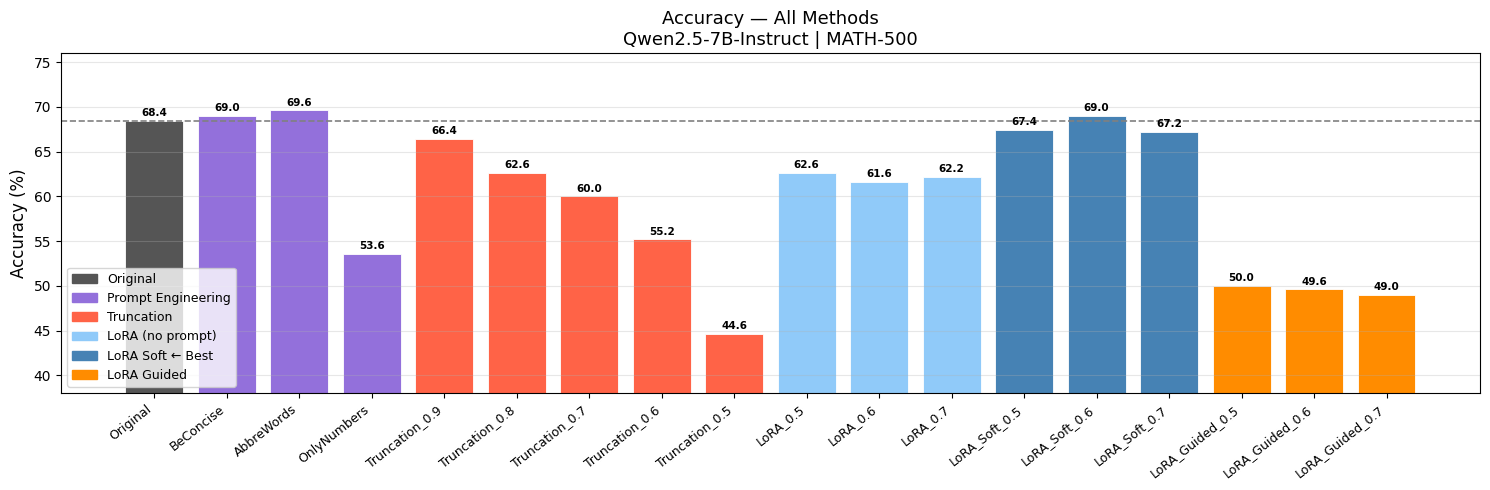

In [29]:
ordered_methods = [
    'Original', 'BeConcise', 'AbbreWords', 'OnlyNumbers',
    'Truncation_0.9', 'Truncation_0.8', 'Truncation_0.7', 'Truncation_0.6', 'Truncation_0.5',
    'LoRA_0.5', 'LoRA_0.6', 'LoRA_0.7',
    'LoRA_Soft_0.5', 'LoRA_Soft_0.6', 'LoRA_Soft_0.7',
    'LoRA_Guided_0.5', 'LoRA_Guided_0.6', 'LoRA_Guided_0.7',
]
bar_df = final_df[final_df['Method'].isin(ordered_methods)].set_index('Method').reindex(ordered_methods).dropna(subset=['Accuracy'])

bar_colors = []
for m in bar_df.index:
    if m == 'Original':            bar_colors.append(COLORS['origin'])
    elif m.startswith('Truncation'):bar_colors.append(COLORS['trunc'])
    elif m.startswith('LoRA_Soft'): bar_colors.append(COLORS['soft'])
    elif m.startswith('LoRA_Guided'):bar_colors.append(COLORS['guided'])
    elif m.startswith('LoRA_'):     bar_colors.append(COLORS['orig'])
    else:                           bar_colors.append(COLORS['prompt'])

fig, ax = plt.subplots(figsize=(15, 5))
bars = ax.bar(range(len(bar_df)), bar_df['Accuracy'], color=bar_colors, edgecolor='white', linewidth=0.6)
ax.axhline(ORIG_ACC, linestyle='--', color='gray', lw=1.2, label=f'Original ({ORIG_ACC}%)')
ax.set_xticks(range(len(bar_df)))
ax.set_xticklabels(bar_df.index, rotation=38, ha='right', fontsize=9)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy — All Methods\nQwen2.5-7B-Instruct | MATH-500', fontsize=13)
ax.set_ylim(38, 76)
for bar, val in zip(bars, bar_df['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
from matplotlib.patches import Patch
legend_elements = [
    Patch(color=COLORS['origin'],  label='Original'),
    Patch(color=COLORS['prompt'],  label='Prompt Engineering'),
    Patch(color=COLORS['trunc'],   label='Truncation'),
    Patch(color=COLORS['orig'],    label='LoRA (no prompt)'),
    Patch(color=COLORS['soft'],    label='LoRA Soft ← Best'),
    Patch(color=COLORS['guided'],  label='LoRA Guided'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/fig3_accuracy_all_methods.png', dpi=300, bbox_inches='tight')
plt.show()


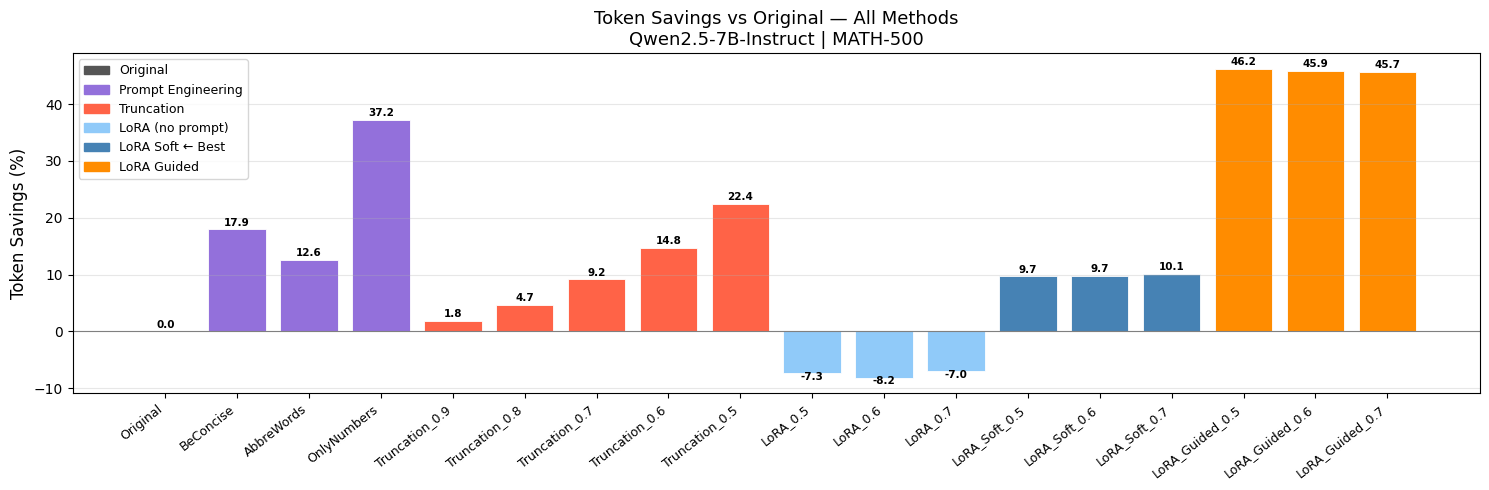

In [30]:
fig, ax = plt.subplots(figsize=(15, 5))
bars = ax.bar(range(len(bar_df)), bar_df['Token Savings (%)'], color=bar_colors, edgecolor='white', linewidth=0.6)
ax.axhline(0, linestyle='-', color='gray', lw=0.8)
ax.set_xticks(range(len(bar_df)))
ax.set_xticklabels(bar_df.index, rotation=38, ha='right', fontsize=9)
ax.set_ylabel('Token Savings (%)', fontsize=12)
ax.set_title('Token Savings vs Original — All Methods\nQwen2.5-7B-Instruct | MATH-500', fontsize=13)
for bar, val in zip(bars, bar_df['Token Savings (%)']):
    ypos = bar.get_height() + 0.3 if val >= 0 else bar.get_height() - 1.5
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:.1f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax.legend(handles=legend_elements, fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/fig4_token_savings_all_methods.png', dpi=300, bbox_inches='tight')
plt.show()


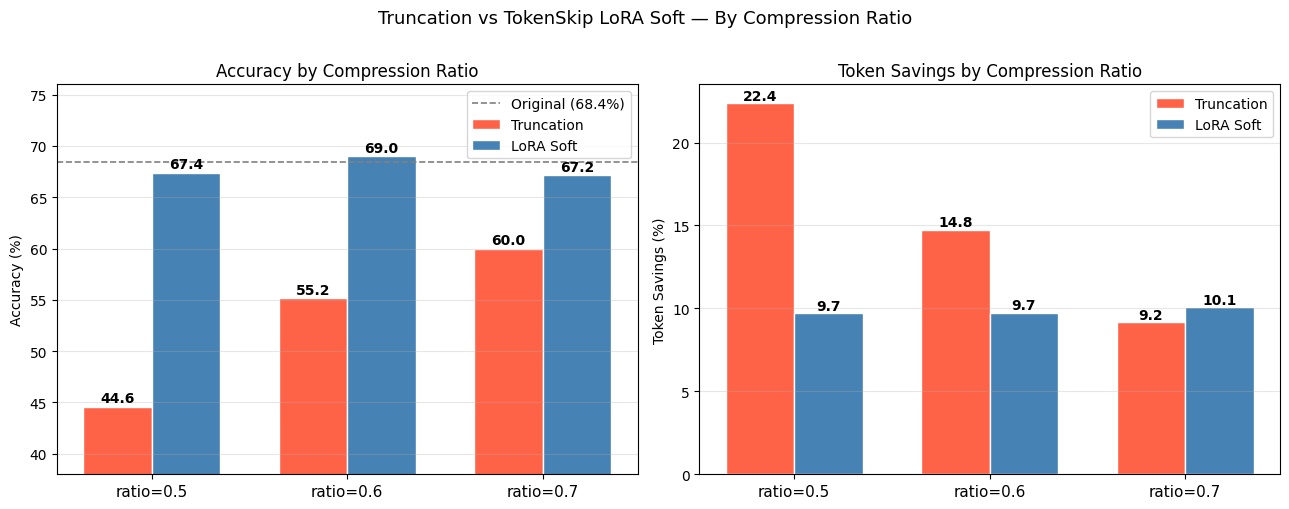

In [25]:
import numpy as np
ratios = [0.5, 0.6, 0.7]
t_acc  = [final_df.loc[final_df['Method']==f'Truncation_{r}', 'Accuracy'].values[0]      for r in ratios]
s_acc  = [final_df.loc[final_df['Method']==f'LoRA_Soft_{r}',  'Accuracy'].values[0]      for r in ratios]
t_sav  = [final_df.loc[final_df['Method']==f'Truncation_{r}', 'Token Savings (%)'].values[0] for r in ratios]
s_sav  = [final_df.loc[final_df['Method']==f'LoRA_Soft_{r}',  'Token Savings (%)'].values[0] for r in ratios]

x = np.arange(len(ratios)); w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accuracy subplot
b1 = axes[0].bar(x - w/2, t_acc, w, label='Truncation', color=COLORS['trunc'], edgecolor='white')
b2 = axes[0].bar(x + w/2, s_acc, w, label='LoRA Soft',  color=COLORS['soft'],  edgecolor='white')
axes[0].axhline(ORIG_ACC, linestyle='--', color='gray', lw=1.2, label=f'Original ({ORIG_ACC}%)')
axes[0].set_xticks(x); axes[0].set_xticklabels([f'ratio={r}' for r in ratios], fontsize=11)
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_title('Accuracy by Compression Ratio')
axes[0].set_ylim(38, 76); axes[0].legend(fontsize=10); axes[0].grid(axis='y', alpha=0.3)
for i, (a, b) in enumerate(zip(t_acc, s_acc)):
    axes[0].text(i-w/2, a+0.4, f'{a:.1f}', ha='center', fontsize=10, fontweight='bold')
    axes[0].text(i+w/2, b+0.4, f'{b:.1f}', ha='center', fontsize=10, fontweight='bold')

# Token savings subplot
axes[1].bar(x - w/2, t_sav, w, label='Truncation', color=COLORS['trunc'], edgecolor='white')
axes[1].bar(x + w/2, s_sav, w, label='LoRA Soft',  color=COLORS['soft'],  edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels([f'ratio={r}' for r in ratios], fontsize=11)
axes[1].set_ylabel('Token Savings (%)'); axes[1].set_title('Token Savings by Compression Ratio')
axes[1].legend(fontsize=10); axes[1].grid(axis='y', alpha=0.3)
for i, (a, b) in enumerate(zip(t_sav, s_sav)):
    axes[1].text(i-w/2, a+0.2, f'{a:.1f}', ha='center', fontsize=10, fontweight='bold')
    axes[1].text(i+w/2, b+0.2, f'{b:.1f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Truncation vs TokenSkip LoRA Soft — By Compression Ratio', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/fig5_grouped_by_ratio.png', dpi=300, bbox_inches='tight')
plt.show()


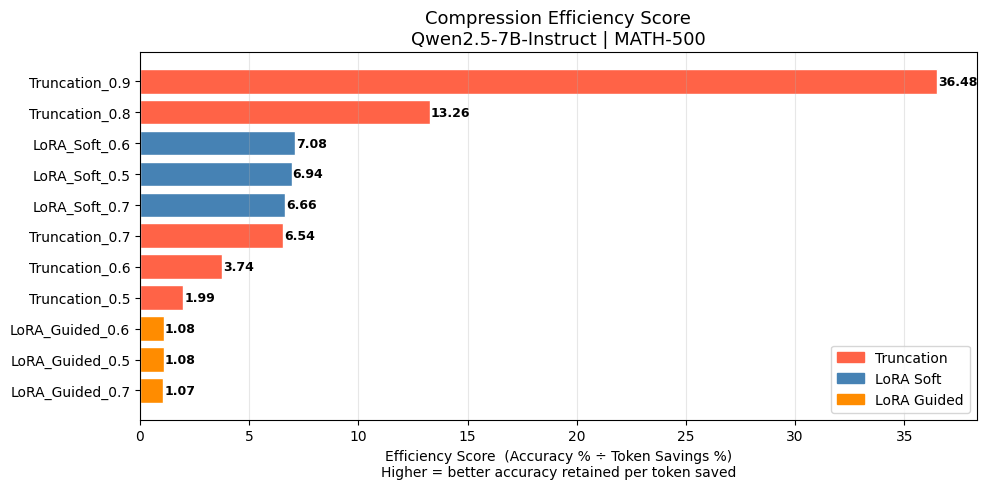

In [26]:
eff_methods = (list(final_df[final_df['Method'].str.startswith('Truncation')]['Method']) +
               list(final_df[final_df['Method'].str.startswith('LoRA_Soft')]['Method']) +
               list(final_df[final_df['Method'].str.startswith('LoRA_Guided')]['Method']))
eff_df = final_df[final_df['Method'].isin(eff_methods)].copy()
eff_df = eff_df[eff_df['Token Savings (%)'] > 0].copy()
eff_df['Efficiency'] = (eff_df['Accuracy'] / eff_df['Token Savings (%)']).round(3)
eff_df = eff_df.sort_values('Efficiency', ascending=True)

eff_colors = [COLORS['trunc'] if 'Truncation' in m else
              (COLORS['soft'] if 'Soft' in m else COLORS['guided'])
              for m in eff_df['Method']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(eff_df['Method'], eff_df['Efficiency'], color=eff_colors, edgecolor='white')
for bar, val in zip(bars, eff_df['Efficiency']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Efficiency Score  (Accuracy % ÷ Token Savings %)\nHigher = better accuracy retained per token saved', fontsize=10)
ax.set_title('Compression Efficiency Score\nQwen2.5-7B-Instruct | MATH-500', fontsize=13)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=COLORS['trunc'], label='Truncation'),
                   Patch(color=COLORS['soft'],  label='LoRA Soft'),
                   Patch(color=COLORS['guided'],label='LoRA Guided')], fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/fig6_efficiency_score.png', dpi=300, bbox_inches='tight')
plt.show()


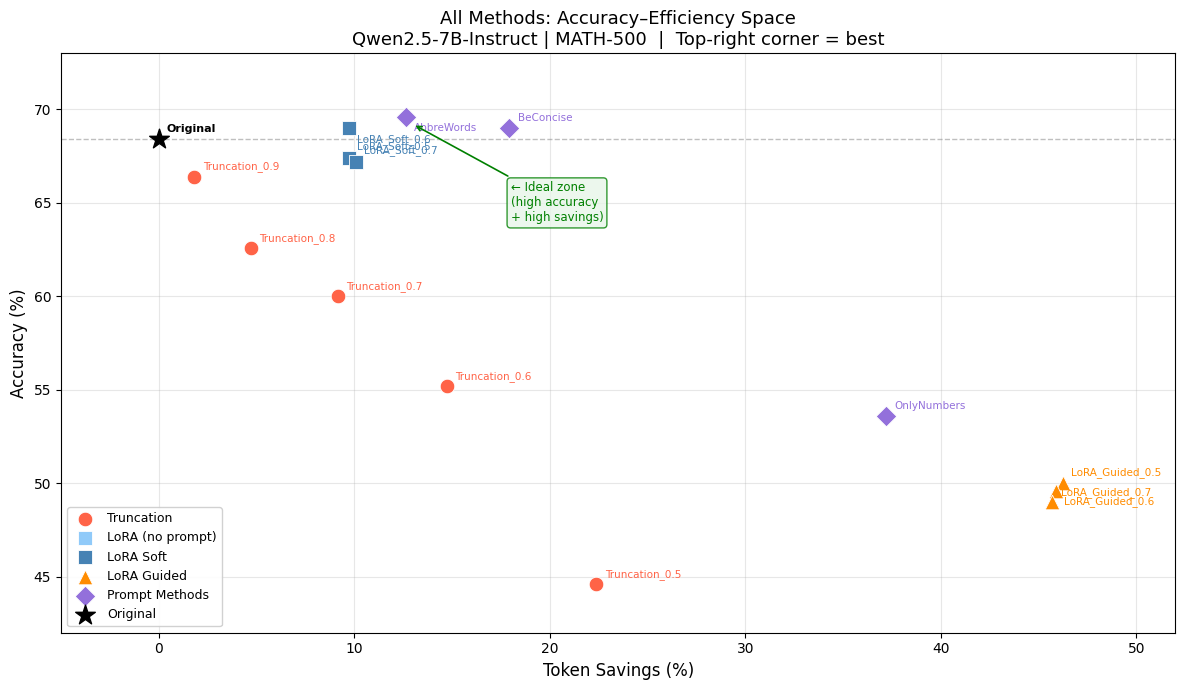

In [28]:
# ══════════════════════════════════════════════════════════════
# FIG 7 — Scatter: All methods in accuracy-savings space (FIXED)
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 7))

scatter_groups = {
    'Truncation':       (COLORS['trunc'],  'o', final_df[final_df['Method'].str.startswith('Truncation')]),
    'LoRA (no prompt)': (COLORS['orig'],   's', final_df[final_df['Method'].str.match(r'^LoRA_[0-9]')]),
    'LoRA Soft':        (COLORS['soft'],   's', final_df[final_df['Method'].str.startswith('LoRA_Soft')]),
    'LoRA Guided':      (COLORS['guided'], '^', final_df[final_df['Method'].str.startswith('LoRA_Guided')]),
    'Prompt Methods':   (COLORS['prompt'], 'D', final_df[final_df['Method'].isin(['BeConcise','AbbreWords','OnlyNumbers'])]),
}

# Manual label offsets to prevent overlap: {Method: (dx, dy)}
label_offsets = {
    'LoRA_Soft_0.5':    ( 6,  6),
    'LoRA_Soft_0.6':    ( 6, -10),
    'LoRA_Soft_0.7':    ( 6,  6),
    'LoRA_0.5':         (-55,  5),
    'LoRA_0.6':         (-55, -10),
    'LoRA_0.7':         (-55,  5),
    'LoRA_Guided_0.5':  ( 6,  6),
    'LoRA_Guided_0.6':  ( 6, -10),
    'LoRA_Guided_0.7':  ( 6,  5),
    'Truncation_0.9':   ( 6,  5),
    'Truncation_0.8':   ( 6,  5),
    'Truncation_0.7':   ( 6,  5),
    'Truncation_0.6':   ( 6,  5),
    'Truncation_0.5':   ( 6,  5),
    'BeConcise':        ( 6,  5),
    'AbbreWords':       ( 6, -10),
    'OnlyNumbers':      ( 6,  5),
}

for label, (color, marker, subset) in scatter_groups.items():
    ax.scatter(subset['Token Savings (%)'], subset['Accuracy'],
               color=color, marker=marker, s=110, label=label,
               zorder=3, edgecolors='white', linewidth=0.6)
    for _, row in subset.iterrows():
        dx, dy = label_offsets.get(row['Method'], (6, 4))
        ax.annotate(row['Method'],
                    (row['Token Savings (%)'], row['Accuracy']),
                    textcoords='offset points', xytext=(dx, dy),
                    fontsize=7.5, color=color)

# Original star
ax.scatter([0], [ORIG_ACC], color='black', marker='*', s=220, zorder=5, label='Original')
ax.annotate('Original', (0, ORIG_ACC), textcoords='offset points',
            xytext=(6, 5), fontsize=8, fontweight='bold')
ax.axhline(ORIG_ACC, linestyle='--', color='gray', lw=1, alpha=0.5)

# Ideal zone — moved to BOTTOM RIGHT of annotation, away from data
ax.annotate('← Ideal zone\n(high accuracy\n+ high savings)',
            xy=(13, 69.2),          # points to LoRA_Soft cluster
            xytext=(18, 64),        # annotation box sits below the cluster
            fontsize=8.5, color='green',
            arrowprops=dict(arrowstyle='->', color='green', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', fc='#e8f5e9', ec='green', alpha=0.8))

ax.set_xlim(-5, 52)   # no wasted negative space
ax.set_ylim(42, 73)
ax.set_xlabel('Token Savings (%)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('All Methods: Accuracy–Efficiency Space\nQwen2.5-7B-Instruct | MATH-500  |  Top-right corner = best',
             fontsize=13)
ax.legend(fontsize=9, loc='lower left', framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/fig7_scatter_all_methods.png', dpi=300, bbox_inches='tight')
plt.show()
